In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [5]:
BASE_DIR = Path("/content/drive/MyDrive/rostat")

PRICE_DIR = BASE_DIR / "processed"
FORECAST_DIR = BASE_DIR / "monthly_forecast"
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

prices_long = pd.read_csv(
    PRICE_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    PRICE_DIR / "product_dictionary.csv"
)

prices = prices_long.merge(
    products[
        [
            "product_code",
            "product_name",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices["year"] = prices["date"].dt.year

# 2026 неполный, поэтому для обучения и прогноза его лучше исключить
prices = prices[prices["year"] <= 2025].copy()

prices["month_end"] = prices["date"].dt.to_period("M").dt.to_timestamp("M")

prices_monthly = (
    prices
    .groupby(["month_end", "product_group_code", "product_group_name"], as_index=False)
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        n_products=("product_code", "nunique"),
        n_observations=("price", "size")
    )
    .sort_values(["product_group_code", "month_end"])
)

prices_monthly.head()

,month_end,product_group_code,product_group_name,mean_price,median_price,n_products,n_observations
0,2016-01-31,G01,"Хлеб, крупы, мука и макаронные изделия",64.656250,65.110,8,24
9,2016-02-29,G01,"Хлеб, крупы, мука и макаронные изделия",65.140750,65.300,8,40
18,2016-03-31,G01,"Хлеб, крупы, мука и макаронные изделия",65.685000,65.710,8,32
27,2016-04-30,G01,"Хлеб, крупы, мука и макаронные изделия",66.366563,66.160,8,32
36,2016-05-31,G01,"Хлеб, крупы, мука и макаронные изделия",67.327750,66.135,8,40


In [6]:
full_months = pd.date_range(
    start=prices_monthly["month_end"].min(),
    end=prices_monthly["month_end"].max(),
    freq="M"
)

groups = (
    prices_monthly[["product_group_code", "product_group_name"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

full_grid = (
    groups
    .assign(key=1)
    .merge(
        pd.DataFrame({"month_end": full_months, "key": 1}),
        on="key",
        how="outer"
    )
    .drop(columns="key")
)

monthly_full = full_grid.merge(
    prices_monthly,
    on=["month_end", "product_group_code", "product_group_name"],
    how="left"
)

monthly_full["is_imputed"] = monthly_full["median_price"].isna()

monthly_full = monthly_full.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

cols_to_interpolate = [
    "mean_price",
    "median_price",
    "n_products",
    "n_observations"
]

for col in cols_to_interpolate:
    monthly_full[col] = (
        monthly_full
        .groupby("product_group_code")[col]
        .transform(lambda x: x.interpolate(method="linear"))
    )

monthly_full["year"] = monthly_full["month_end"].dt.year
monthly_full["month"] = monthly_full["month_end"].dt.month

In [7]:
monthly_full = monthly_full.sort_values(
    ["product_group_code", "month_end"]
).copy()

monthly_full["price_index"] = (
    monthly_full["median_price"] /
    monthly_full.groupby("product_group_code")["median_price"].transform("first")
) * 100

monthly_full.head()

,product_group_code,product_group_name,month_end,mean_price,median_price,n_products,n_observations,is_imputed,year,month,price_index
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,64.656250,65.110,8.0,24.0,False,2016,1,100.000000
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-02-29,65.140750,65.300,8.0,40.0,False,2016,2,100.291814
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,65.685000,65.710,8.0,32.0,False,2016,3,100.921517
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-04-30,66.366563,66.160,8.0,32.0,False,2016,4,101.612656
4,G01,"Хлеб, крупы, мука и макаронные изделия",2016-05-31,67.327750,66.135,8.0,40.0,False,2016,5,101.574259


In [8]:
monthly_check = (
    monthly_full
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        n_months=("month_end", "nunique"),
        start_date=("month_end", "min"),
        end_date=("month_end", "max"),
        imputed_months=("is_imputed", "sum"),
        missing_price_index=("price_index", lambda x: x.isna().sum())
    )
)

display(monthly_check)

,product_group_code,product_group_name,n_months,start_date,end_date,imputed_months,missing_price_index
0,G01,"Хлеб, крупы, мука и макаронные изделия",120,2016-01-31,2025-12-31,12,0
1,G02,Молочная продукция и яйца,120,2016-01-31,2025-12-31,12,0
2,G03,"Мясо, птица, рыба и колбасные изделия",120,2016-01-31,2025-12-31,12,0
3,G04,"Овощи, фрукты и картофель",120,2016-01-31,2025-12-31,12,0
4,G05,"Бакалея, масло, сахар, чай, соль",120,2016-01-31,2025-12-31,12,0
5,G07,"Товары для дома, гигиены и бытовая химия",120,2016-01-31,2025-12-31,12,0
6,G10,Топливо и транспортные товары,120,2016-01-31,2025-12-31,12,0
7,G11,Услуги,120,2016-01-31,2025-12-31,12,0
8,G99,Прочее,120,2016-01-31,2025-12-31,12,0


In [9]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [10]:
monthly_configs = [
    {
        "model": "SARIMA (0,1,1)(0,1,1,12)",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,12)",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (1,1,1)(0,1,1,12)",
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (0,1,1)(1,1,0,12)",
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 0, 12)
    }
]

In [11]:
def run_monthly_seasonal_naive(category_df, validation_size=12):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df.iloc[:-validation_size].copy()
    valid_df = df.iloc[-validation_size:].copy()

    yhat = df["price_index"].iloc[-validation_size - 12:-12].values

    pred = valid_df[
        [
            "month_end",
            "product_group_code",
            "product_group_name",
            "price_index",
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred["price_index"]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [12]:
def run_monthly_sarima(category_df, config, validation_size=12):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df.iloc[:-validation_size].copy()
    valid_df = df.iloc[-validation_size:].copy()

    y_train = np.log1p(train_df["price_index"])
    y_valid = valid_df["price_index"].values

    model = SARIMAX(
        y_train,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(
        steps=len(valid_df)
    )

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[
        [
            "month_end",
            "product_group_code",
            "product_group_name",
            "price_index",
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = yhat
    pred["model"] = config["model"]
    pred["model_type"] = "SARIMA"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": config["model"],
        "model_type": "SARIMA",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [13]:
monthly_metrics = []
monthly_predictions = []
monthly_models = {}

validation_size = 12

for group_code, category_df in monthly_full.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("month_end").copy()

    if category_df["month_end"].nunique() < 48:
        print("Пропуск: слишком мало месяцев")
        continue

    try:
        naive_pred, naive_metrics = run_monthly_seasonal_naive(
            category_df,
            validation_size=validation_size
        )

        monthly_predictions.append(naive_pred)
        monthly_metrics.append(naive_metrics)

        print(
            f"Seasonal Naive | "
            f"MAPE={naive_metrics['MAPE']:.3f}, "
            f"sMAPE={naive_metrics['sMAPE']:.3f}"
        )

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    for config in monthly_configs:
        try:
            result, pred, metrics = run_monthly_sarima(
                category_df,
                config=config,
                validation_size=validation_size
            )

            monthly_predictions.append(pred)
            monthly_metrics.append(metrics)

            model_key = f"{group_code}_{config['model']}"
            monthly_models[model_key] = result

            print(
                f"{config['model']} | "
                f"MAPE={metrics['MAPE']:.3f}, "
                f"sMAPE={metrics['sMAPE']:.3f}"
            )

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

monthly_metrics_df = pd.DataFrame(monthly_metrics)
monthly_predictions_df = pd.concat(monthly_predictions, ignore_index=True)

display(monthly_metrics_df.head())

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=7.225, sMAPE=7.511
SARIMA (0,1,1)(0,1,1,12) | MAPE=1.915, sMAPE=1.938
SARIMA (1,1,0)(0,1,1,12) | MAPE=1.104, sMAPE=1.113
SARIMA (1,1,1)(0,1,1,12) | MAPE=1.124, sMAPE=1.133
SARIMA (0,1,1)(1,1,0,12) | MAPE=9.196, sMAPE=9.715
Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=9.152, sMAPE=9.632
SARIMA (0,1,1)(0,1,1,12) | MAPE=1.286, sMAPE=1.265
SARIMA (1,1,0)(0,1,1,12) | MAPE=2.311, sMAPE=2.261
SARIMA (1,1,1)(0,1,1,12) | MAPE=1.652, sMAPE=1.620
SARIMA (0,1,1)(1,1,0,12) | MAPE=2.460, sMAPE=2.423
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Seasonal Naive | MAPE=5.060, sMAPE=5.192
SARIMA (0,1,1)(0,1,1,12) | MAPE=1.218, sMAPE=1.210
SARIMA (1,1,0)(0,1,1,12) | MAPE=1.588, sMAPE=1.574
SARIMA (1,1,1)(0,1,1,12) | MAPE=1.546, sMAPE=1.533
SARIMA (0,1,1)(1,1,0,12) | MAPE=0.518, sMAPE=0.515
Категория: G04 — Овощи, фрукты и картофель
Seasonal Naive | MAPE=19.979, sMAPE=21.933
SARIMA (0,1,1)(0,1,1,12) 

,MAE,RMSE,MAPE,sMAPE,model,model_type,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,AIC,BIC
0,11.582962,11.903465,7.225230,7.510591,Seasonal Naive,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,NaN,NaN
1,3.082425,3.414288,1.915484,1.937990,"SARIMA (0,1,1)(0,1,1,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,-430.055704,-422.872356
2,1.778140,2.135678,1.104220,1.112953,"SARIMA (1,1,0)(0,1,1,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,-455.403439,-448.183281
3,1.810048,2.176884,1.123836,1.132916,"SARIMA (1,1,1)(0,1,1,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,-447.006774,-437.428977
4,14.801922,15.980323,9.196462,9.714571,"SARIMA (0,1,1)(1,1,0,12)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2024-12-31,2025-01-31,2025-12-31,-420.132808,-412.876286


In [14]:
best_monthly_models = (
    monthly_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_monthly_models_display = best_monthly_models.copy()

for col in ["MAE", "RMSE", "MAPE", "sMAPE", "AIC", "BIC"]:
    if col in best_monthly_models_display.columns:
        best_monthly_models_display[col] = best_monthly_models_display[col].round(3)

display(
    best_monthly_models_display[
        [
            "product_group_code",
            "product_group_name",
            "model",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end"
        ]
    ]
)

,product_group_code,product_group_name,model,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end
0,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",1.778,2.136,1.104,1.113,2016-01-31,2024-12-31,2025-01-31,2025-12-31
1,G02,Молочная продукция и яйца,"SARIMA (0,1,1)(0,1,1,12)",2.469,4.113,1.286,1.265,2016-01-31,2024-12-31,2025-01-31,2025-12-31
2,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (0,1,1)(1,1,0,12)",0.901,1.337,0.518,0.515,2016-01-31,2024-12-31,2025-01-31,2025-12-31
3,G04,"Овощи, фрукты и картофель","SARIMA (0,1,1)(0,1,1,12)",28.837,35.402,17.206,15.060,2016-01-31,2024-12-31,2025-01-31,2025-12-31
4,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (1,1,0)(0,1,1,12)",3.774,4.280,1.820,1.841,2016-01-31,2024-12-31,2025-01-31,2025-12-31
5,G07,"Товары для дома, гигиены и бытовая химия",Seasonal Naive,1.759,2.220,1.086,1.095,2016-01-31,2024-12-31,2025-01-31,2025-12-31
6,G10,Топливо и транспортные товары,"SARIMA (0,1,1)(1,1,0,12)",1.664,2.123,0.911,0.912,2016-01-31,2024-12-31,2025-01-31,2025-12-31
7,G11,Услуги,"SARIMA (1,1,1)(0,1,1,12)",10.201,10.328,5.268,5.414,2016-01-31,2024-12-31,2025-01-31,2025-12-31
8,G99,Прочее,"SARIMA (1,1,0)(0,1,1,12)",8.040,10.745,4.201,4.361,2016-01-31,2024-12-31,2025-01-31,2025-12-31


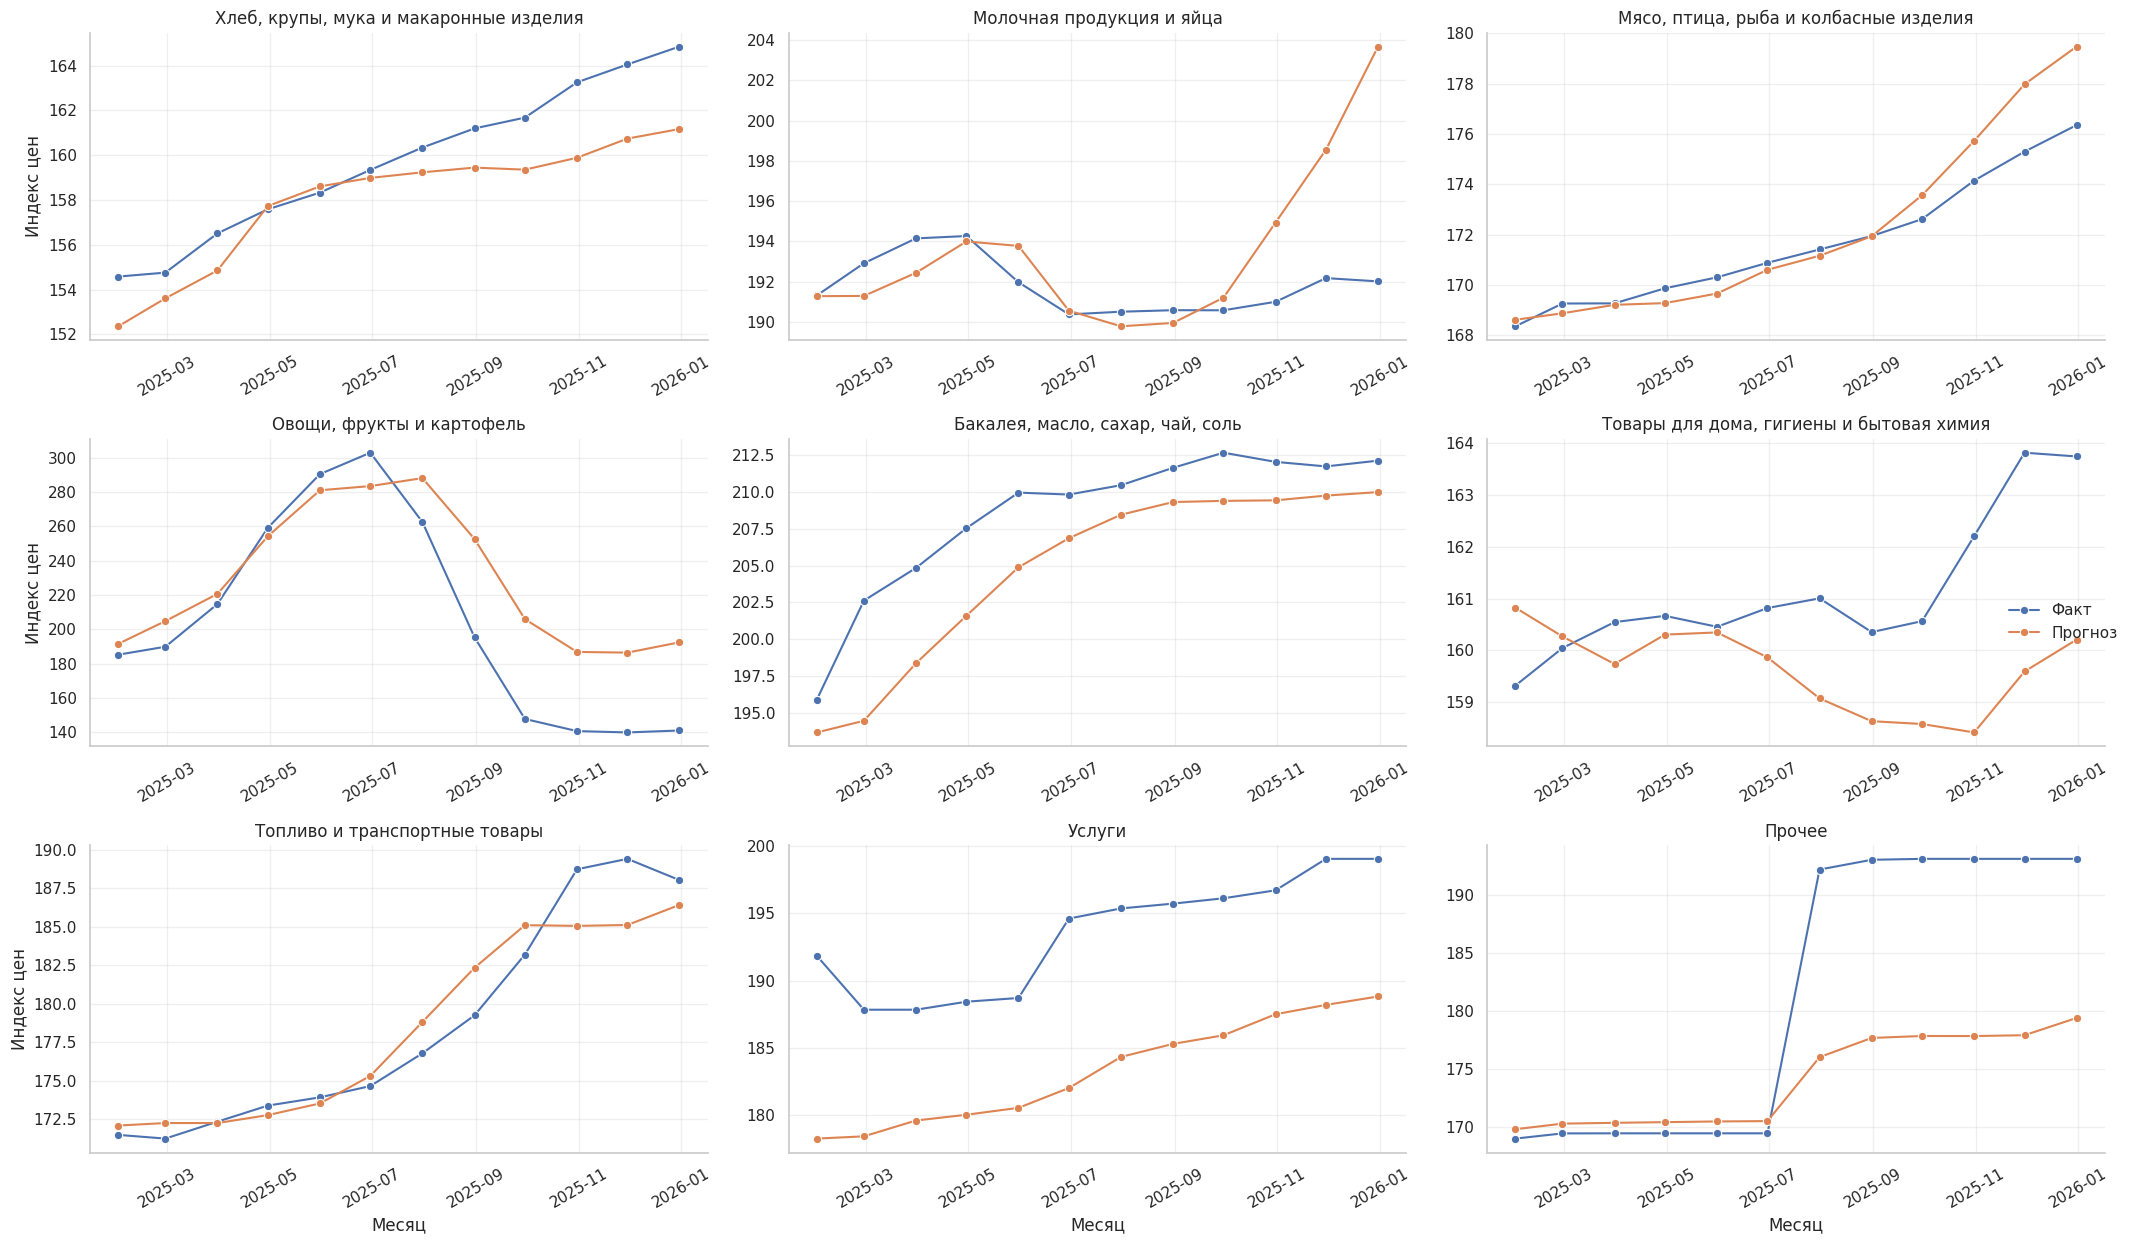

In [15]:
best_keys = best_monthly_models[
    ["product_group_code", "model"]
].copy()

best_monthly_predictions = monthly_predictions_df.merge(
    best_keys,
    on=["product_group_code", "model"],
    how="inner"
)

plot_monthly_validation = pd.concat(
    [
        best_monthly_predictions[
            ["month_end", "product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_monthly_predictions[
            ["month_end", "product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_monthly_validation,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Месяц", "Индекс цен")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
def fit_final_and_forecast_monthly(category_df, best_model_row, forecast_horizon=12):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    model_name = best_model_row["model"]

    if model_name == "Seasonal Naive":
        last_year_values = df["price_index"].iloc[-12:].values
        yhat = np.resize(last_year_values, forecast_horizon)

        result = None

    else:
        config = next(
            item for item in monthly_configs
            if item["model"] == model_name
        )

        y_train = np.log1p(df["price_index"])

        model = SARIMAX(
            y_train,
            order=config["order"],
            seasonal_order=config["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(
            disp=False,
            maxiter=300
        )

        forecast_log = result.forecast(
            steps=forecast_horizon
        )

        yhat = np.expm1(forecast_log)
        yhat = np.maximum(yhat, 0)

    future_months = pd.date_range(
        start=df["month_end"].max() + pd.offsets.MonthEnd(1),
        periods=forecast_horizon,
        freq="M"
    )

    forecast_df = pd.DataFrame({
        "month_end": future_months,
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "model": model_name,
        "price_index_forecast": yhat
    })

    return result, forecast_df

In [17]:
future_forecasts = []
final_monthly_models = {}

forecast_horizon = 12

for _, row in best_monthly_models.iterrows():
    group_code = row["product_group_code"]

    category_df = monthly_full[
        monthly_full["product_group_code"] == group_code
    ].copy()

    result, forecast_df = fit_final_and_forecast_monthly(
        category_df,
        best_model_row=row,
        forecast_horizon=forecast_horizon
    )

    future_forecasts.append(forecast_df)

    if result is not None:
        final_monthly_models[group_code] = result

monthly_future_forecast_df = pd.concat(
    future_forecasts,
    ignore_index=True
)

display(monthly_future_forecast_df.head())

,month_end,product_group_code,product_group_name,model,price_index_forecast
0,2026-01-31,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",165.365328
1,2026-02-28,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",166.390096
2,2026-03-31,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",167.637759
3,2026-04-30,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",170.439425
4,2026-05-31,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",171.295365


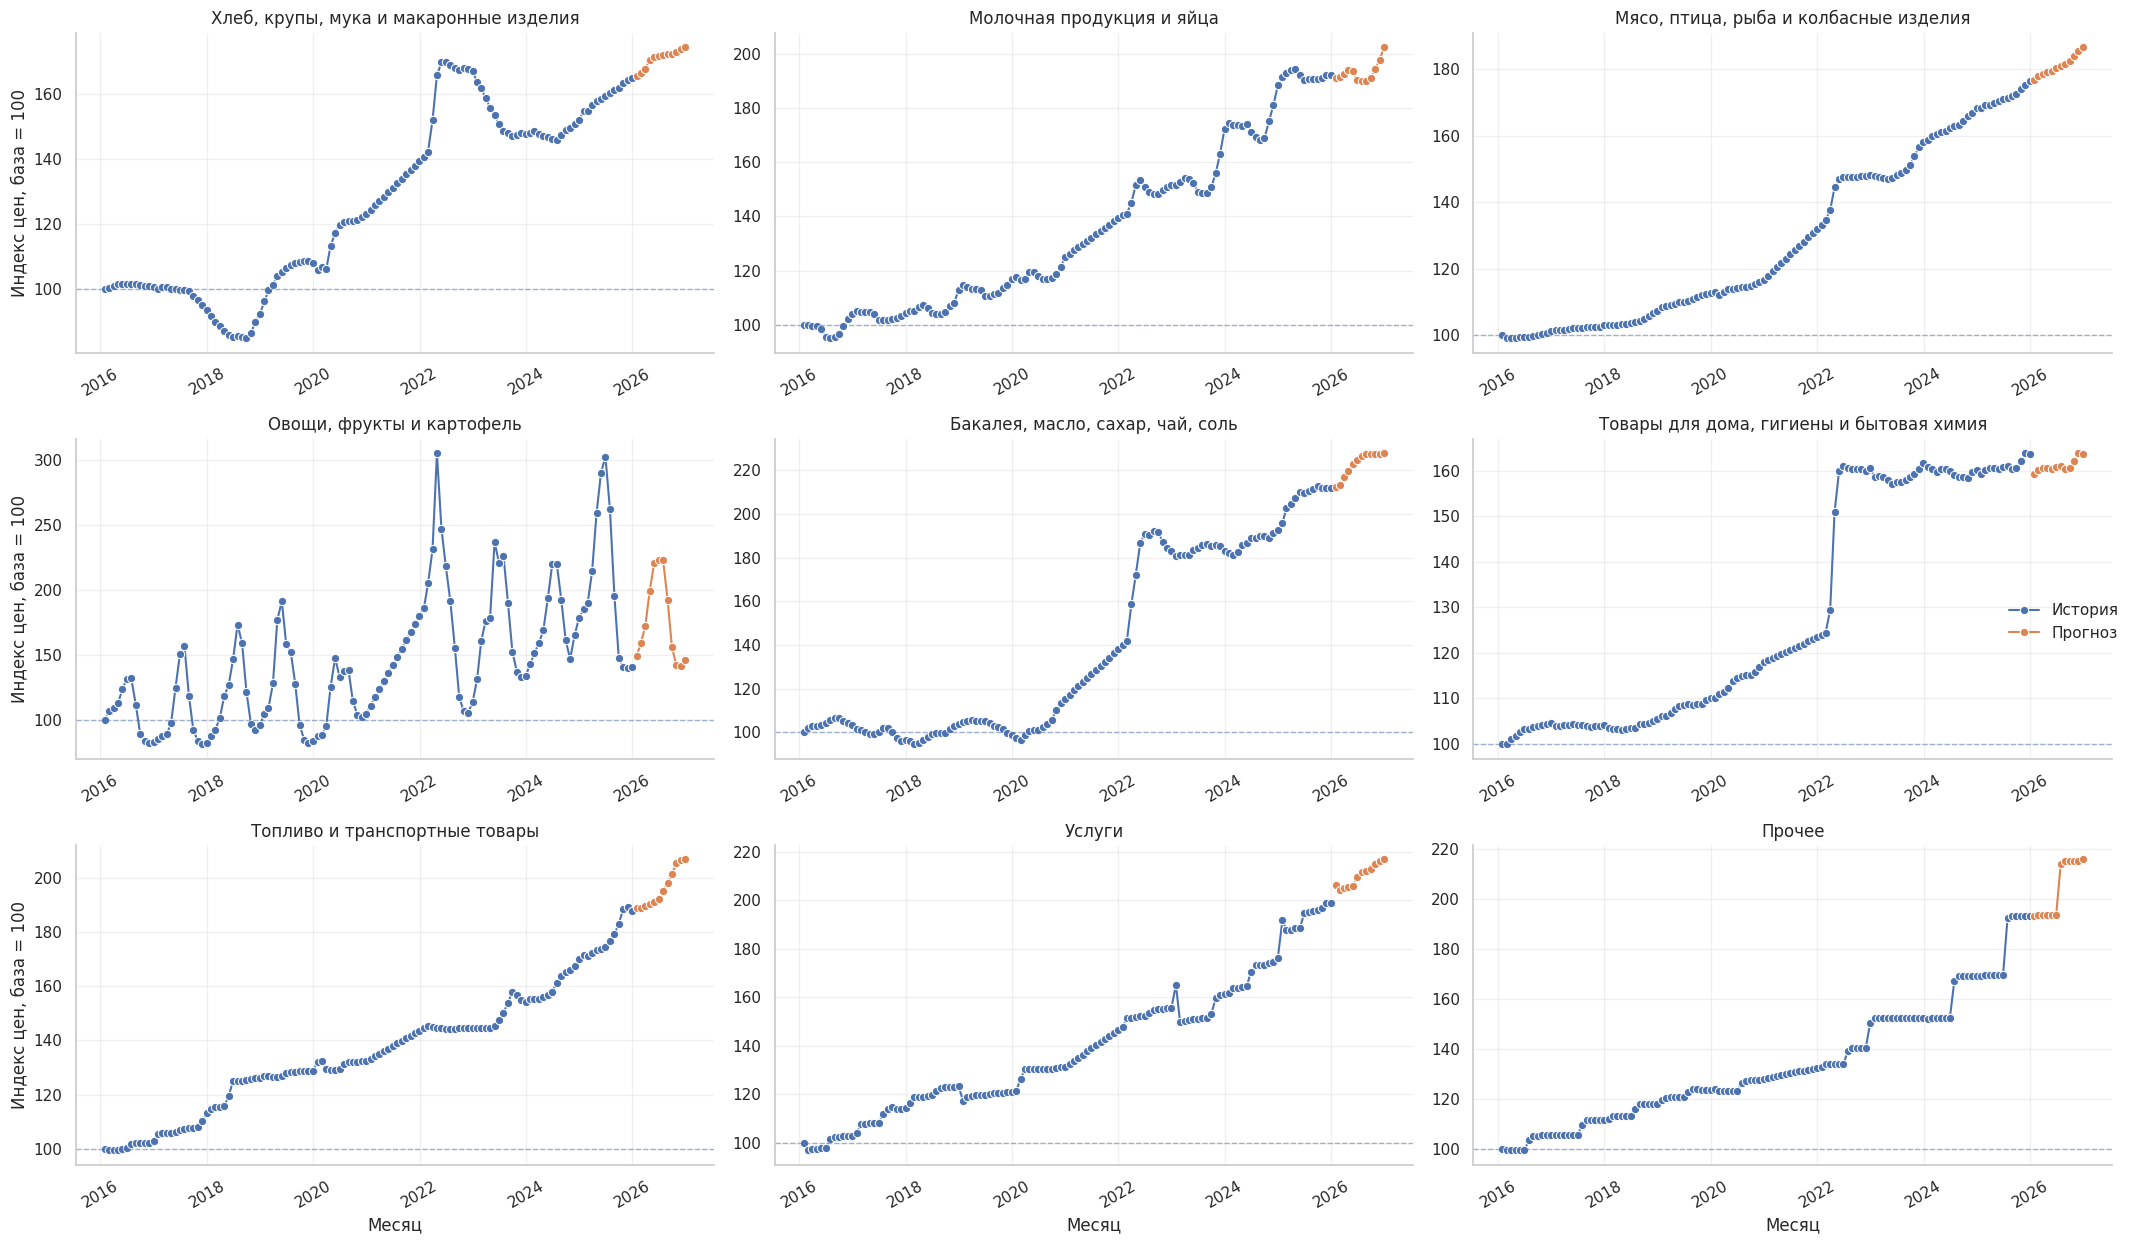

In [18]:
history_plot = monthly_full[
    [
        "month_end",
        "product_group_code",
        "product_group_name",
        "price_index"
    ]
].rename(columns={"price_index": "value"})

history_plot["series"] = "История"

forecast_plot = monthly_future_forecast_df[
    [
        "month_end",
        "product_group_code",
        "product_group_name",
        "price_index_forecast"
    ]
].rename(columns={"price_index_forecast": "value"})

forecast_plot["series"] = "Прогноз"

plot_history_forecast = pd.concat(
    [history_plot, forecast_plot],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_history_forecast,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Месяц", "Индекс цен, база = 100")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.axhline(100, linestyle="--", linewidth=1, alpha=0.5)
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
monthly_full.to_csv(
    FORECAST_DIR / "monthly_price_index_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_metrics_df.to_csv(
    FORECAST_DIR / "monthly_model_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

best_monthly_models.to_csv(
    FORECAST_DIR / "monthly_best_models_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_predictions_df.to_csv(
    FORECAST_DIR / "monthly_validation_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

monthly_future_forecast_df.to_csv(
    FORECAST_DIR / "monthly_future_forecast_12m.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены в:", FORECAST_DIR)

Файлы сохранены в: /content/drive/MyDrive/rostat/monthly_forecast
